# Bootstrap Coverage by Method (`exact` vs `ij`)

Aggregate coverage from `results/metrics_*.json` and plot coverage vs `B_prefix` with one line per `bootstrap_method`.

In [23]:
from pathlib import Path
import json
import re

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
JSON_GLOB = "metrics_*.json"

# Optional filters
FILTER_SPLIT = "test"            # "train" or "test"
FILTER_ALPHA = 0.05              # None to disable
FILTER_K = 20                     # None to disable
FILTER_ATTN_KIND = "raw_scores" # "raw_scores" or "attn"
FILTER_SEED = None               # e.g. 1

# Which coverage statistic to plot:
#   "uniform_all_covered", "uniform_fraction_covered",
#   "pointwise_all_covered", "pointwise_fraction_covered"
COVERAGE_METRIC = "uniform_all_covered"

# Optional B prefix filter
FILTER_B_MAX = None              # e.g. 100


In [25]:
def _parse_method(payload: dict, file_name: str) -> str:
    method = (
        payload.get("bootstrap", {})
        .get("bootstrap_method", "")
        .strip()
        .lower()
    )
    if method in {"exact", "ij", "both"}:
        return method
    # fallback from filename tokens (older runs)
    if "_mexact_" in file_name:
        return "exact"
    if "_mij_" in file_name:
        return "ij"
    return "unknown"


def _parse_seed(payload: dict, file_name: str):
    seed = payload.get("train_cfg_attn", {}).get("seed")
    if seed is not None:
        return int(seed)
    m = re.search(r"_(\d+)\.json$", file_name)
    return int(m.group(1)) if m else None


rows = []
for p in sorted(RESULTS_DIR.glob(JSON_GLOB)):
    with p.open("r") as f:
        payload = json.load(f)

    method = _parse_method(payload, p.name)
    seed = _parse_seed(payload, p.name)
    cov_root = payload.get("coverage_by_alpha_k", {})

    for alpha_key, alpha_block in cov_root.items():
        for k_key, k_block in alpha_block.items():
            alpha_val = k_block.get("alpha")
            k_val = k_block.get("k")
            for split in ["train", "test"]:
                split_block = k_block.get(split, {})
                kind_block = split_block.get(FILTER_ATTN_KIND, {})
                by_prefix = kind_block.get("by_prefix", {})
                for b_str, stats in by_prefix.items():
                    b_pref = int(stats.get("B_prefix", int(b_str)))
                    rows.append({
                        "file": p.name,
                        "seed": seed,
                        "method": method,
                        "split": split,
                        "alpha": alpha_val,
                        "k": k_val,
                        "attn_kind": FILTER_ATTN_KIND,
                        "B_prefix": b_pref,
                        "uniform_all_covered": float(stats.get("uniform_all_covered", float("nan"))),
                        "uniform_fraction_covered": float(stats.get("uniform_fraction_covered", float("nan"))),
                        "pointwise_all_covered": float(stats.get("pointwise_all_covered", float("nan"))),
                        "pointwise_fraction_covered": float(stats.get("pointwise_fraction_covered", float("nan"))),
                    })

df = pd.DataFrame(rows)
print("raw rows:", len(df))

if FILTER_SPLIT is not None:
    df = df[df["split"] == FILTER_SPLIT]
if FILTER_ALPHA is not None:
    df = df[df["alpha"] == FILTER_ALPHA]
if FILTER_K is not None:
    df = df[df["k"] == FILTER_K]
if FILTER_SEED is not None:
    df = df[df["seed"] == FILTER_SEED]
if FILTER_B_MAX is not None:
    df = df[df["B_prefix"] <= FILTER_B_MAX]

df = df[df["method"].isin(["exact", "ij"])]
print("rows after filters:", len(df))

agg = (
    df.groupby(["method", "split", "alpha", "k", "B_prefix"], as_index=False)
      .agg(
          n_files=("file", "nunique"),
          coverage_mean=(COVERAGE_METRIC, "mean"),
          coverage_std=(COVERAGE_METRIC, "std"),
      )
      .sort_values(["method", "B_prefix"])
)

print("aggregated rows:", len(agg))
display(agg.head(20))

raw rows: 4160
rows after filters: 520
aggregated rows: 20


,method,split,alpha,k,B_prefix,n_files,coverage_mean,coverage_std
0,exact,test,0.05,20,20,8,0.375000,0.517549
1,exact,test,0.05,20,40,8,0.375000,0.517549
2,exact,test,0.05,20,60,8,0.750000,0.462910
3,exact,test,0.05,20,80,8,1.000000,0.000000
4,exact,test,0.05,20,100,8,0.875000,0.353553
5,exact,test,0.05,20,120,8,1.000000,0.000000
6,exact,test,0.05,20,140,8,1.000000,0.000000
7,exact,test,0.05,20,160,8,1.000000,0.000000
8,exact,test,0.05,20,180,8,1.000000,0.000000
9,exact,test,0.05,20,200,8,1.000000,0.000000


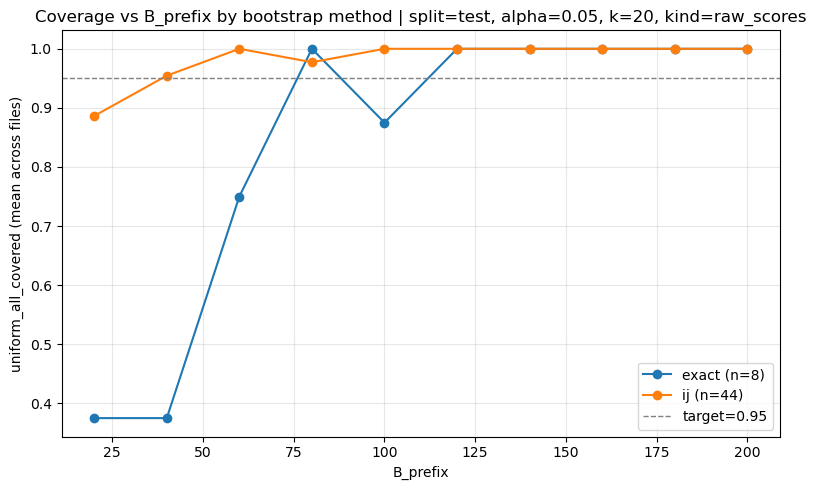

In [26]:
plt.figure(figsize=(8, 5))
for method in ["exact", "ij"]:
    sub = agg[agg["method"] == method].sort_values("B_prefix")
    if sub.empty:
        continue
    plt.plot(sub["B_prefix"], sub["coverage_mean"], marker="o", label=f"{method} (n={int(sub['n_files'].max())})")

target = 1.0 - float(FILTER_ALPHA if FILTER_ALPHA is not None else 0.05)
plt.axhline(target, linestyle="--", color="gray", linewidth=1, label=f"target={target:.2f}")
plt.xlabel("B_prefix")
plt.ylabel(f"{COVERAGE_METRIC} (mean across files)")
plt.title(
    f"Coverage vs B_prefix by bootstrap method | split={FILTER_SPLIT}, alpha={FILTER_ALPHA}, k={FILTER_K}, kind={FILTER_ATTN_KIND}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()